# 准备数据

In [1]:
# 过滤Alphalens的warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [3]:
# 创建数据中心
lab: AlphaLab = AlphaLab("./lab/csi300")

In [4]:
# 设置任务参数
name = "lasso"
index_symbol: str = "000300.SSE"
start: str = "2008-01-01"
end: str = "2023-12-31"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [5]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

# 特征计算

In [6]:
# 加载模块
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_cs_norm,
    process_fill_na
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [7]:
# 加载成分股数据
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

In [8]:
df

datetime,open,high,low,close,volume,turnover,open_interest,vwap,vt_symbol
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,str
2018-10-16 00:00:00,0.833358,1.0,0.833358,1.0,467435.7198,2.9448511e7,0.0,63.00013,"""300760.SZSE"""
2018-10-17 00:00:00,1.100043,1.100043,1.100043,1.100043,207641.7348,1.4420083e7,0.0,69.44694,"""300760.SZSE"""
2018-10-18 00:00:00,1.210047,1.210047,1.044259,1.15227,6.2019e7,4.4940e9,0.0,72.46078,"""300760.SZSE"""
2018-10-19 00:00:00,1.13135,1.26754,1.129928,1.26754,3.9313e7,3.0112e9,0.0,76.59425,"""300760.SZSE"""
2018-10-22 00:00:00,1.337699,1.394337,1.309378,1.394337,1.9686e7,1.6898e9,0.0,85.838755,"""300760.SZSE"""
…,…,…,…,…,…,…,…,…,…
2024-01-04 00:00:00,0.210308,0.215566,0.209257,0.214252,2.0214935e7,1.6344419e8,0.0,8.085319,"""600961.SSE"""
2024-01-05 00:00:00,0.213726,0.218195,0.212148,0.212674,1.2680378e7,1.03784368e8,0.0,8.184643,"""600961.SSE"""
2024-01-08 00:00:00,0.213989,0.214252,0.208468,0.208994,1.0172871e7,8.1537727e7,0.0,8.015213,"""600961.SSE"""


In [9]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period = ("2008-01-01", "2014-12-31"),
    valid_period = ("2015-01-01", "2016-12-31"),
    test_period = ("2017-01-01", "2020-8-31"),
)

In [10]:
# 添加数据预处理器
dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_norm, names=["label"], method="zscore"))

dataset.add_processor("infer", partial(process_fill_na, fill_value=0))

In [11]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [12]:
# 准备特征和标签数据
dataset.prepare_data(filters, max_workers=3)

# 应用数据预处理器
dataset.process_data()

2026-05-11 12:00:09 开始计算表达式因子特征


100%|██████████████████████████████████████████████████████████████████████████████| 159/159 [1:22:48<00:00, 31.25s/it]


2026-05-11 13:23:00 开始合并结果数据因子特征


0it [00:00, ?it/s]


2026-05-11 13:23:01 开始筛选成分股数据


100%|███████████████████████████████████████████████████████████████████████████████| 819/819 [00:06<00:00, 136.37it/s]


Dropped 3.7% entries from factor data: 0.3% in forward returns computation and 3.4% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1.0,0.000000,0.861320,0.118393,0.149608,89010,10.000124
2.0,0.001492,0.929111,0.252826,0.195028,89010,10.000124
3.0,0.010163,0.966824,0.326497,0.216486,89010,10.000124
4.0,0.016945,0.992620,0.388276,0.227563,89007,9.999787
5.0,0.025167,1.000000,0.446862,0.231919,89010,10.000124
6.0,0.036461,1.000000,0.506674,0.230664,89005,9.999562
7.0,0.052632,1.000000,0.571753,0.223189,89007,9.999787
8.0,0.073814,1.000000,0.645603,0.207630,89010,10.000124
9.0,0.109371,1.000000,0.736062,0.178880,89010,10.000124


Returns Analysis


,1D,5D,10D
Ann. alpha,0.030,-0.069,-0.021
beta,0.014,0.009,0.020
Mean Period Wise Return Top Quantile (bps),4.850,-4.139,-1.494
Mean Period Wise Return Bottom Quantile (bps),-3.211,0.712,-0.762
Mean Period Wise Spread (bps),8.061,-4.836,-0.691


<Figure size 640x480 with 0 Axes>

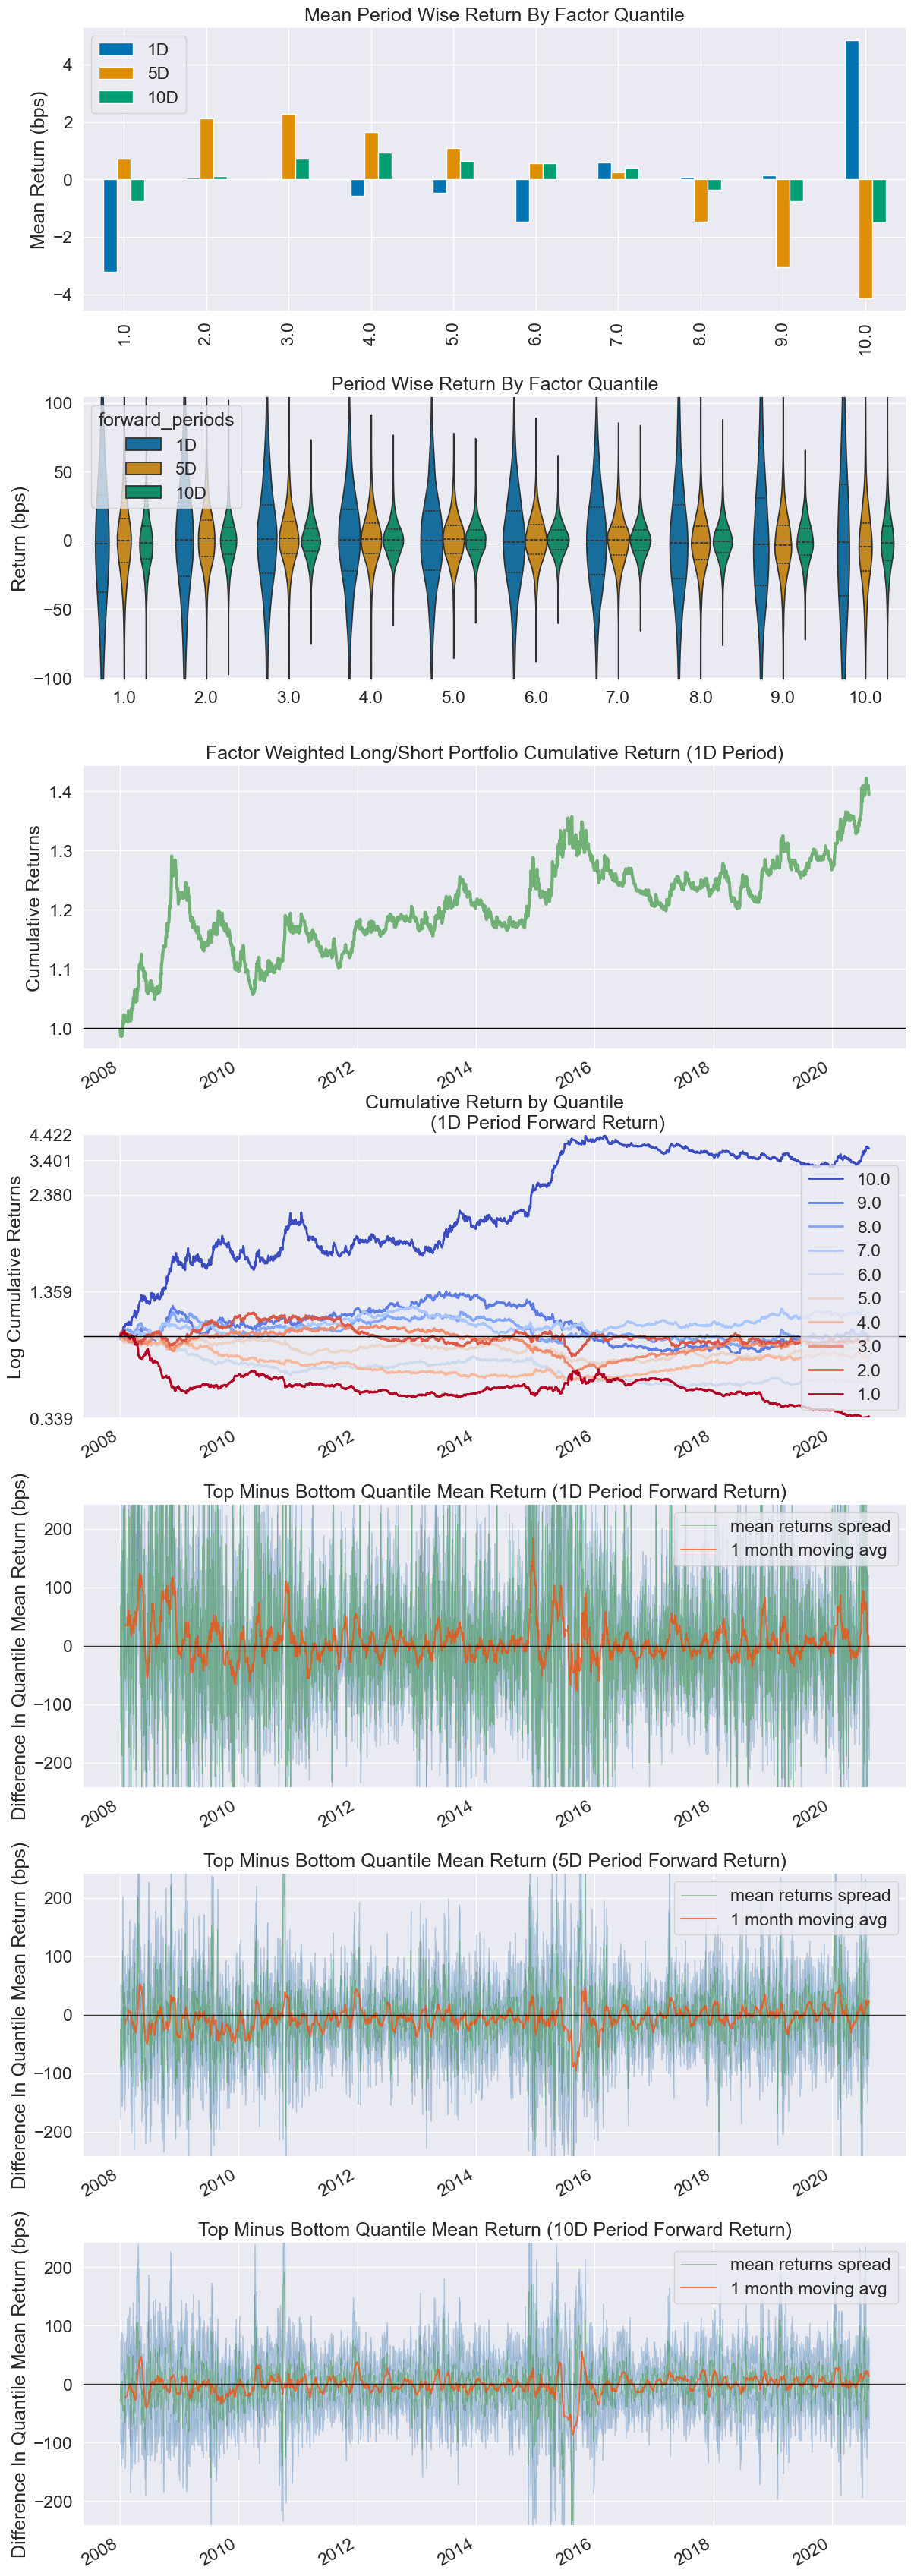

Information Analysis


,1D,5D,10D
IC Mean,-0.034,-0.037,-0.013
IC Std.,0.160,0.150,0.148
Risk-Adjusted IC,-0.214,-0.244,-0.085
t-stat(IC),NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN
IC Skew,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN


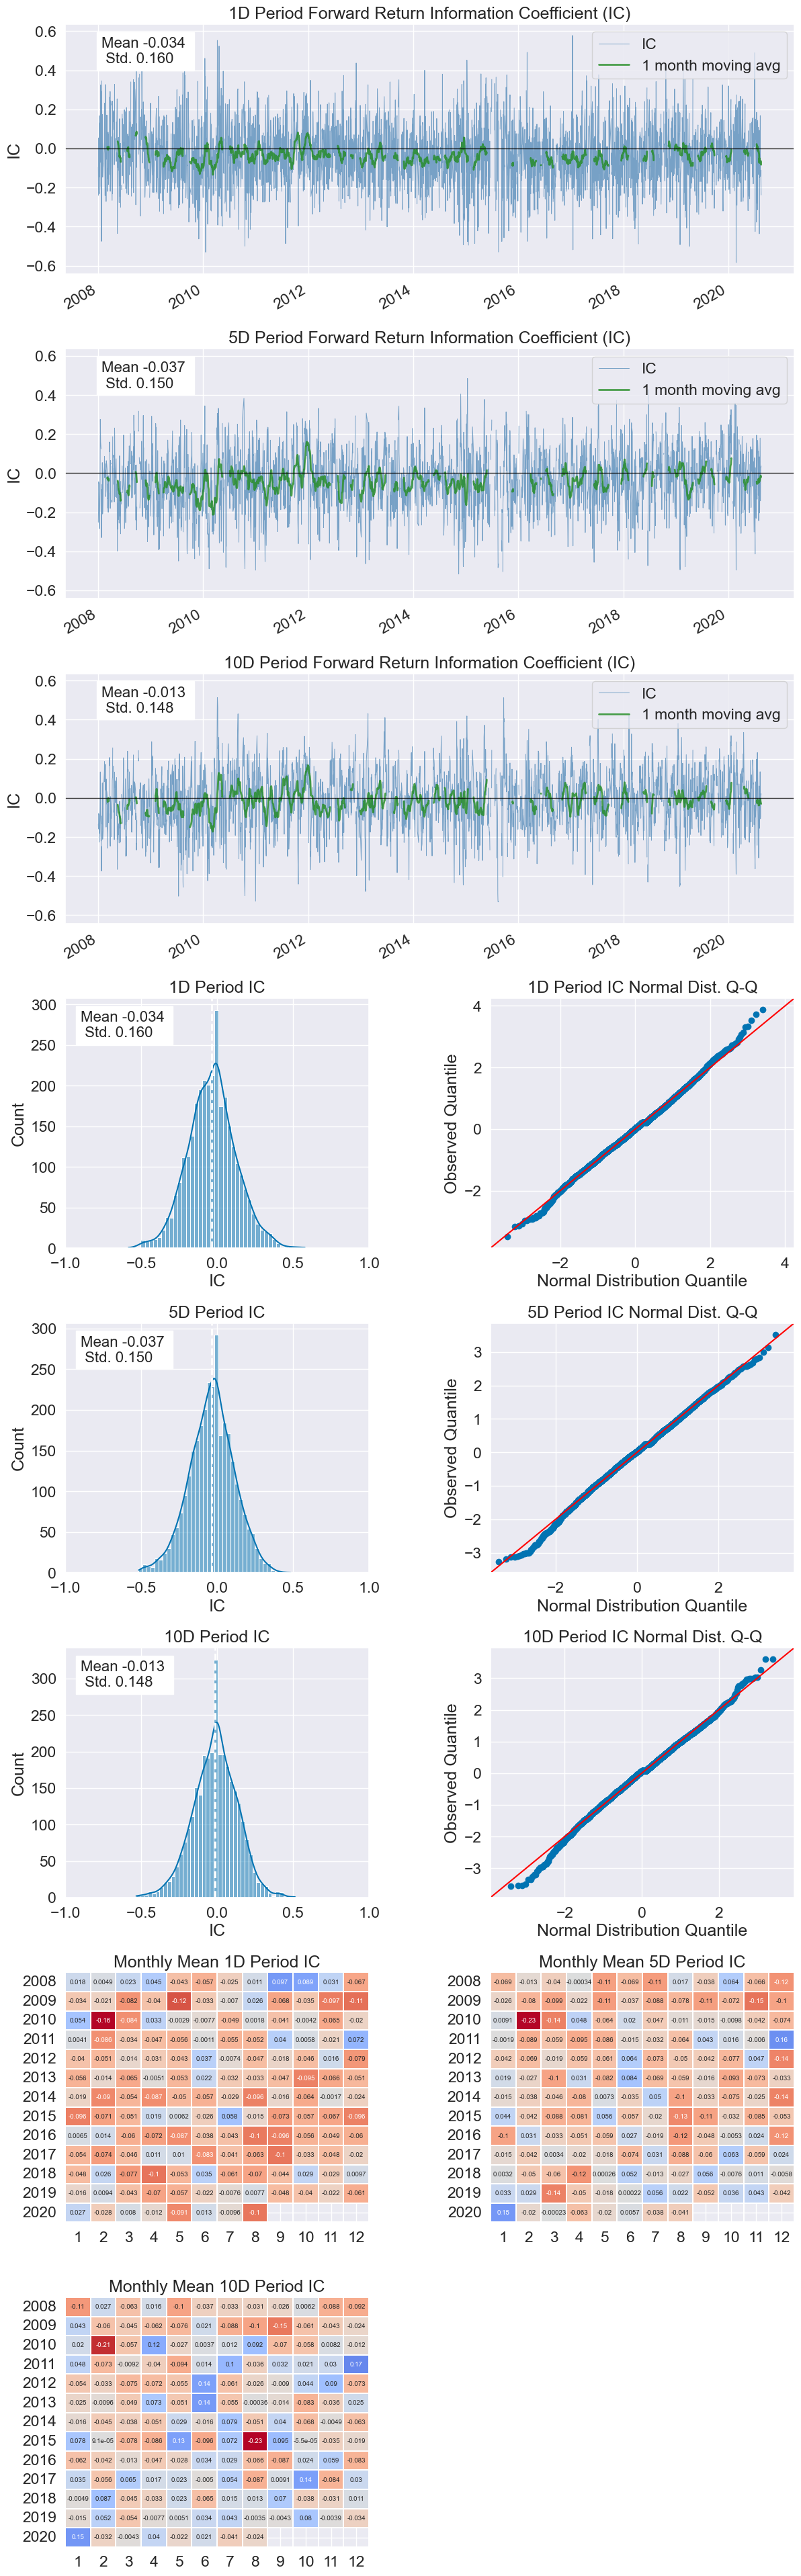

D:\veighna_studio\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1.0 Mean Turnover,0.533,0.746,0.754
Quantile 2.0 Mean Turnover,0.767,0.905,0.896
Quantile 3.0 Mean Turnover,0.827,0.899,0.896
Quantile 4.0 Mean Turnover,0.850,0.896,0.895
Quantile 5.0 Mean Turnover,0.860,0.896,0.896
Quantile 6.0 Mean Turnover,0.861,0.895,0.896
Quantile 7.0 Mean Turnover,0.856,0.900,0.897
Quantile 8.0 Mean Turnover,0.837,0.900,0.899
Quantile 9.0 Mean Turnover,0.795,0.900,0.894
Quantile 10.0 Mean Turnover,0.674,0.897,0.887


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.583,0.011,0.056


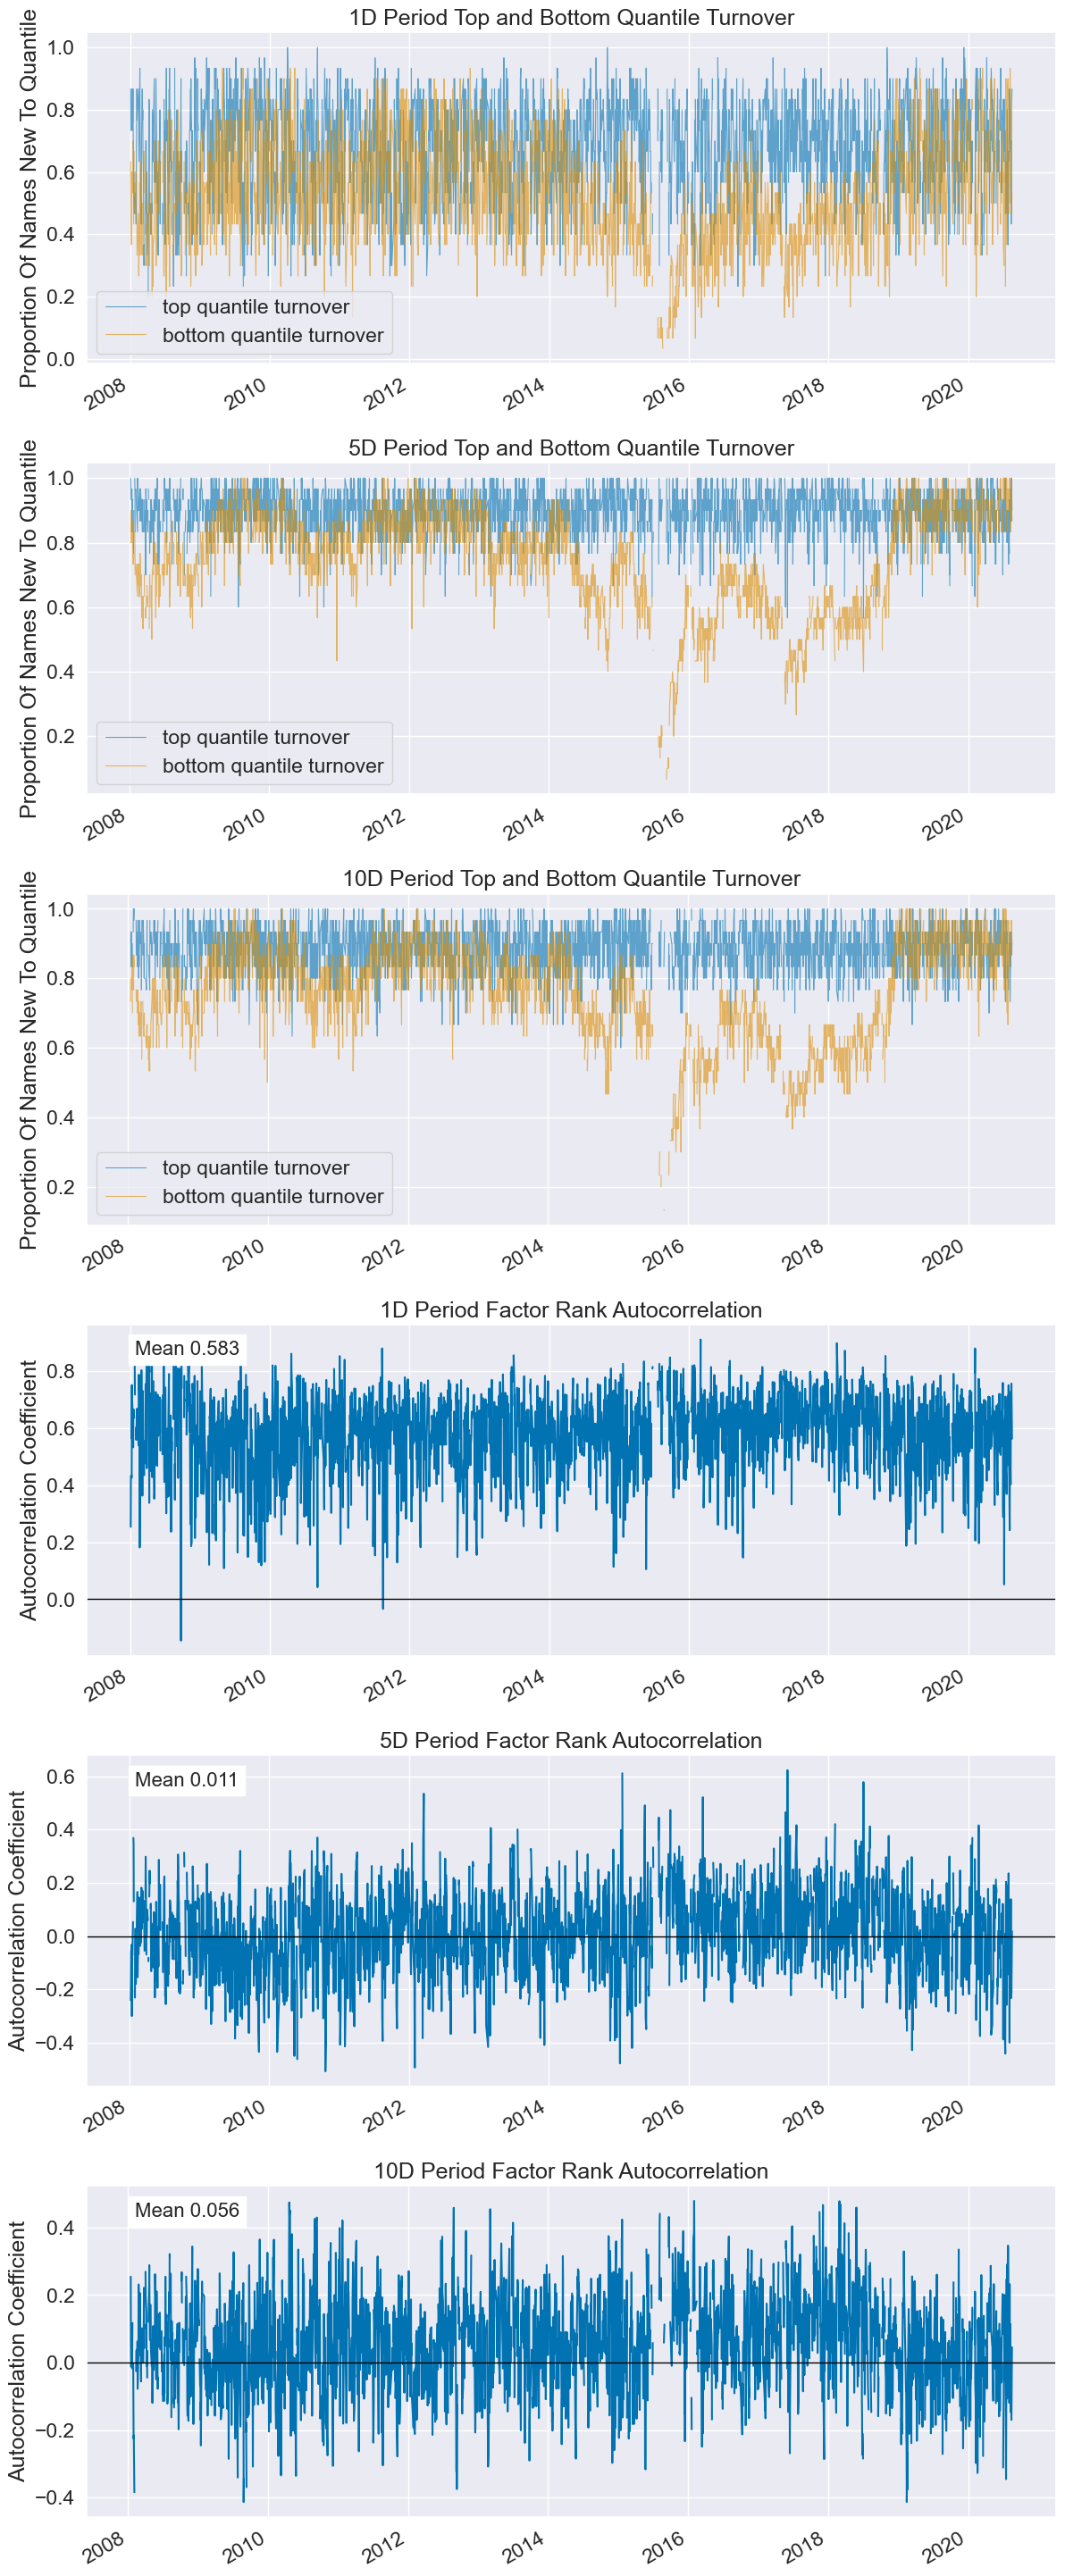

In [13]:
# 特征表现分析
dataset.show_feature_performance("rsv_5")

In [14]:
# 保存到文件缓存
lab.save_dataset(name, dataset)

# 模型训练

In [15]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.lasso_model import LassoModel

In [16]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name)

In [17]:
# 创建模型对象
model: AlphaModel = LassoModel()

In [18]:
# 使用数据集训练模型
model.fit(dataset)

D:\veighna_studio\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.265e+05, tolerance: 6.548e+01
  model = cd_fast.enet_coordinate_descent(


In [19]:
# 查看模型细节
model.detail()

2026-05-11 13:27:09 LASSO模型特征总数量: 46
2026-05-11 13:27:09 roc_30: 0.201147
2026-05-11 13:27:09 ma_5: -0.135721
2026-05-11 13:27:09 rsv_30: 0.093490
2026-05-11 13:27:09 klow_2: -0.066172
2026-05-11 13:27:09 rank_10: -0.063976
2026-05-11 13:27:09 rank_5: -0.051165
2026-05-11 13:27:09 rsv_20: 0.047866
2026-05-11 13:27:09 rank_60: 0.041962
2026-05-11 13:27:09 qtld_5: -0.039833
2026-05-11 13:27:09 max_60: 0.038590
2026-05-11 13:27:09 imxd_5: -0.033326
2026-05-11 13:27:09 rsqr_5: -0.031732
2026-05-11 13:27:09 cord_20: -0.031570
2026-05-11 13:27:09 rsqr_10: -0.026283
2026-05-11 13:27:09 imax_30: -0.025676
2026-05-11 13:27:09 sumd_30: 0.024993
2026-05-11 13:27:09 ksft_2: -0.019634
2026-05-11 13:27:09 rsv_10: 0.018945
2026-05-11 13:27:09 cord_30: -0.017276
2026-05-11 13:27:09 cord_10: -0.014624
2026-05-11 13:27:09 cord_5: -0.013932
2026-05-11 13:27:09 wvma_30: -0.012675
2026-05-11 13:27:09 rsqr_30: -0.011181
2026-05-11 13:27:09 imin_10: 0.011088
2026-05-11 13:27:09 sumd_10: 0.010947
2026-05-11 1

In [20]:
# 保存模型
lab.save_model(name, model)

# 预测信号

In [21]:
model: AlphaModel = lab.load_model(name)

In [22]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

Dropped 1.1% entries from factor data: 1.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.736547,0.012241,-0.082498,0.032413,26460,10.0
2,-0.125012,0.031231,-0.051263,0.023259,26460,10.0
3,-0.104829,0.042750,-0.035281,0.023612,26460,10.0
4,-0.091062,0.052843,-0.022637,0.023880,26460,10.0
5,-0.078246,0.066750,-0.011197,0.023964,26460,10.0
6,-0.066917,0.076269,-0.000168,0.023974,26460,10.0
7,-0.058043,0.084598,0.011248,0.023761,26460,10.0
8,-0.045479,0.094951,0.024004,0.023372,26460,10.0
9,-0.033323,0.110840,0.040217,0.022881,26460,10.0


Returns Analysis


,1D,5D,10D
Ann. alpha,0.200,0.116,0.049
beta,-0.005,0.000,0.005
Mean Period Wise Return Top Quantile (bps),10.456,8.165,5.382
Mean Period Wise Return Bottom Quantile (bps),-12.622,-7.387,-4.064
Mean Period Wise Spread (bps),23.078,15.535,9.445


<Figure size 640x480 with 0 Axes>

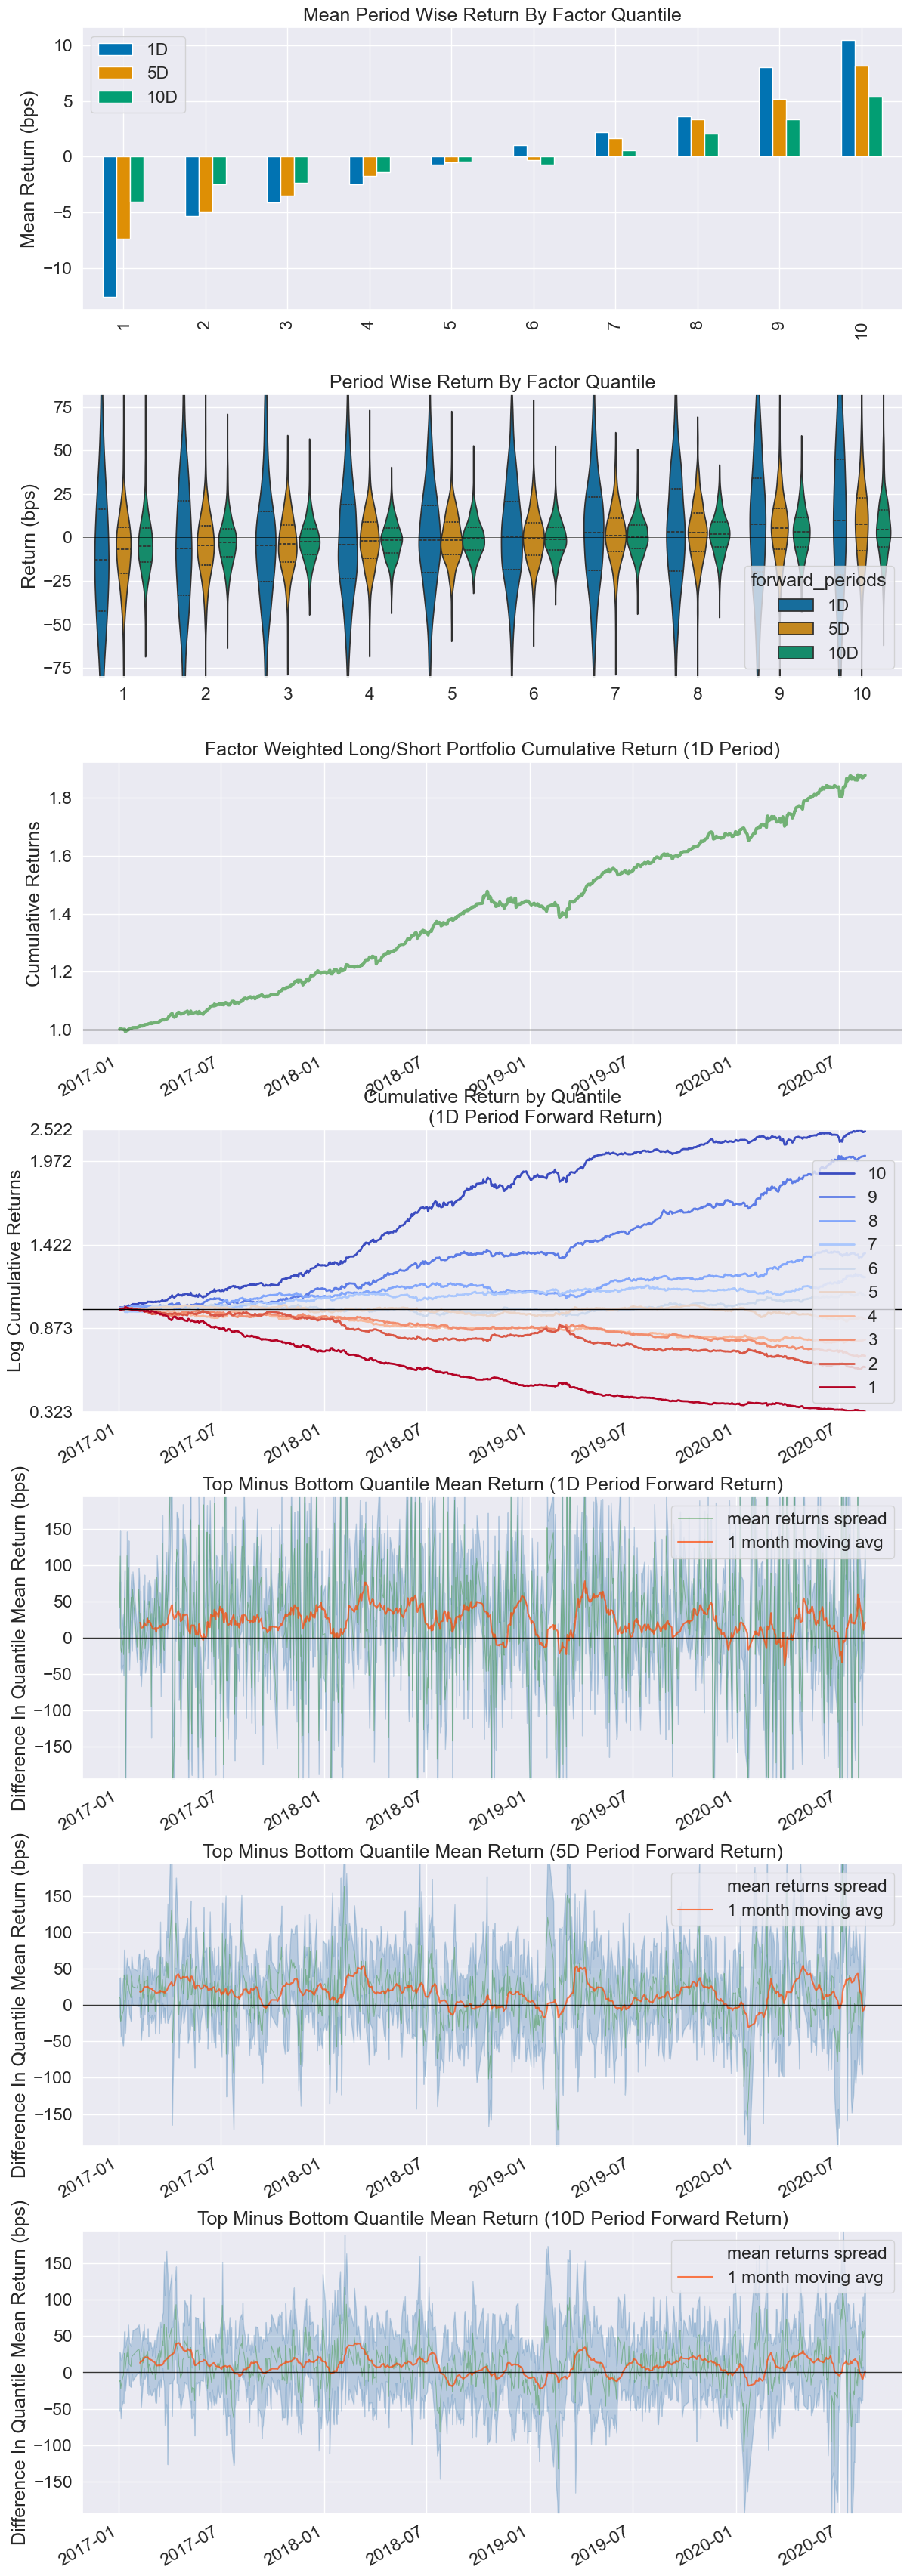

Information Analysis


,1D,5D,10D
IC Mean,0.054,0.060,0.052
IC Std.,0.136,0.131,0.126
Risk-Adjusted IC,0.396,0.456,0.408
t-stat(IC),11.775,13.529,12.125
p-value(IC),0.000,0.000,0.000
IC Skew,0.025,0.069,-0.067
IC Kurtosis,0.104,0.416,0.426


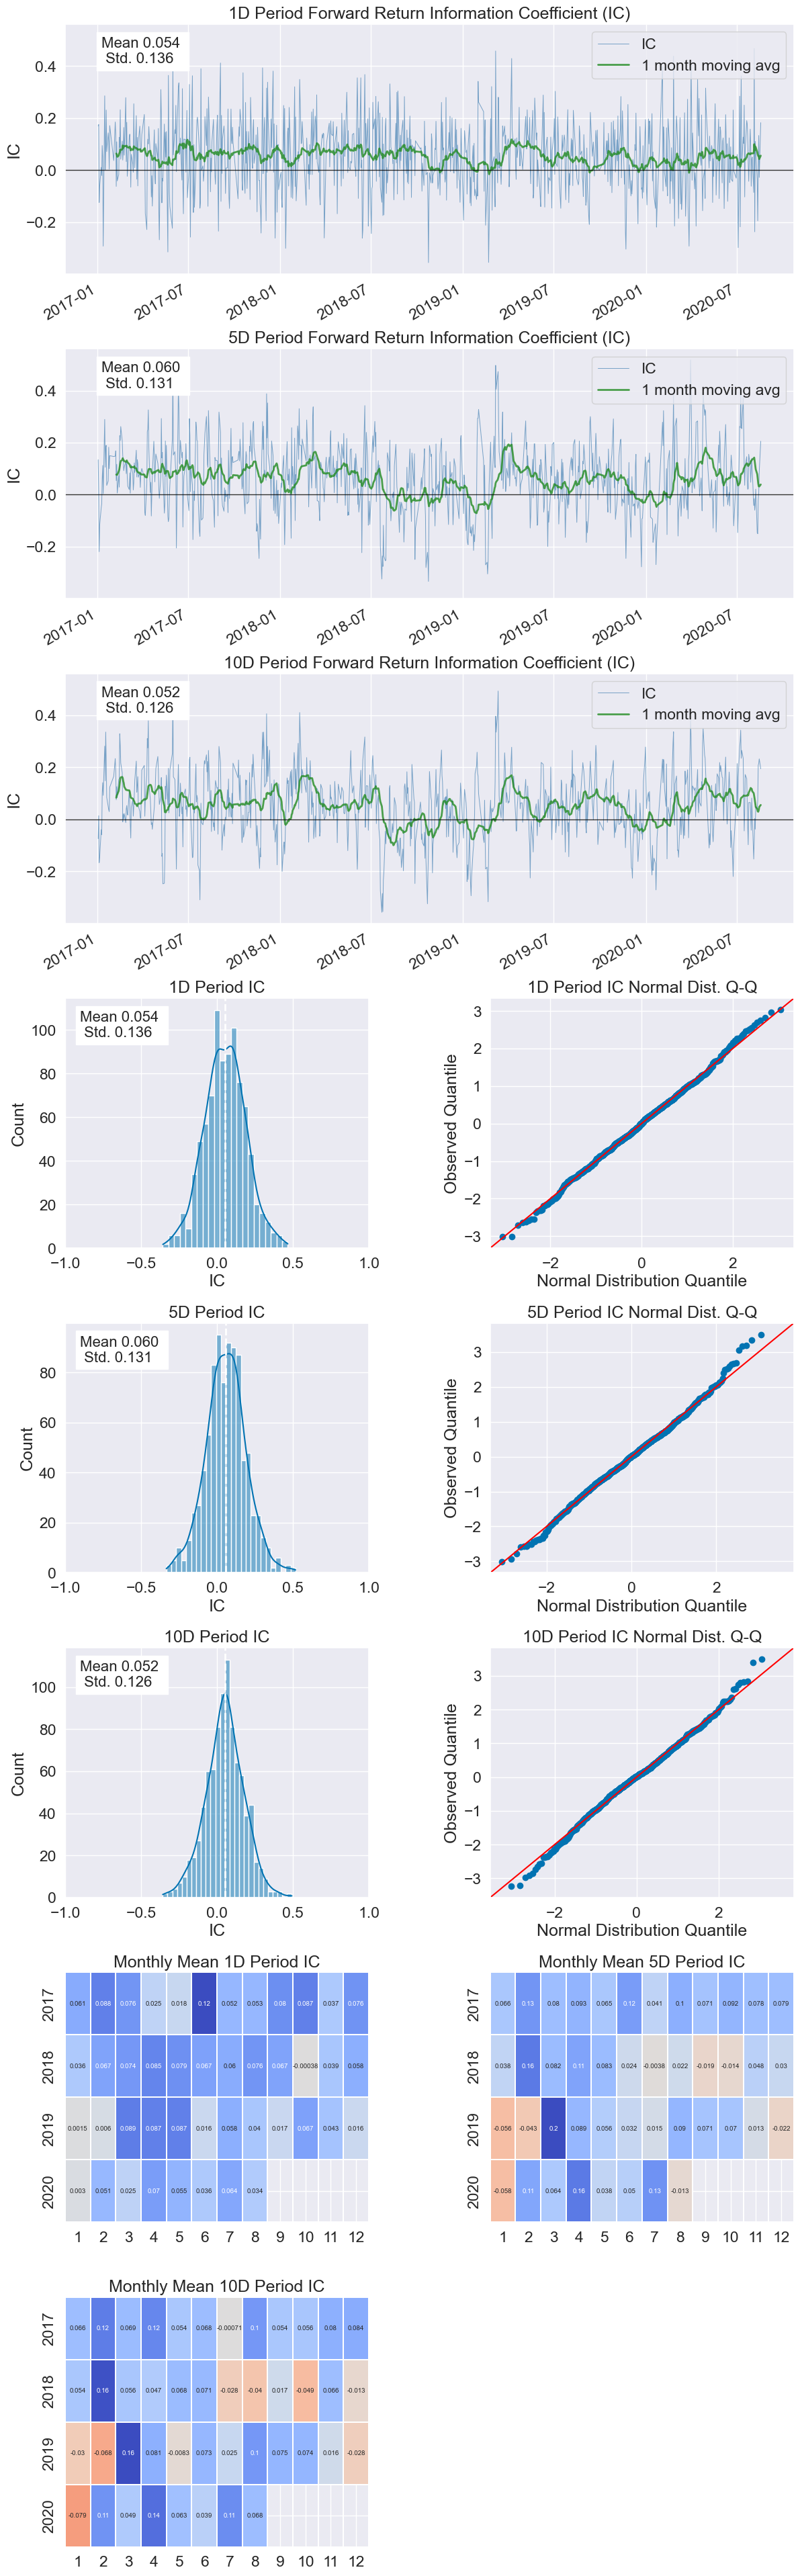

D:\veighna_studio\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.566,0.800,0.832
Quantile 2 Mean Turnover,0.789,0.879,0.888
Quantile 3 Mean Turnover,0.837,0.889,0.892
Quantile 4 Mean Turnover,0.856,0.894,0.896
Quantile 5 Mean Turnover,0.859,0.896,0.897
Quantile 6 Mean Turnover,0.861,0.894,0.896
Quantile 7 Mean Turnover,0.851,0.893,0.899
Quantile 8 Mean Turnover,0.828,0.887,0.892
Quantile 9 Mean Turnover,0.778,0.871,0.879
Quantile 10 Mean Turnover,0.543,0.774,0.802


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.629,0.223,0.16


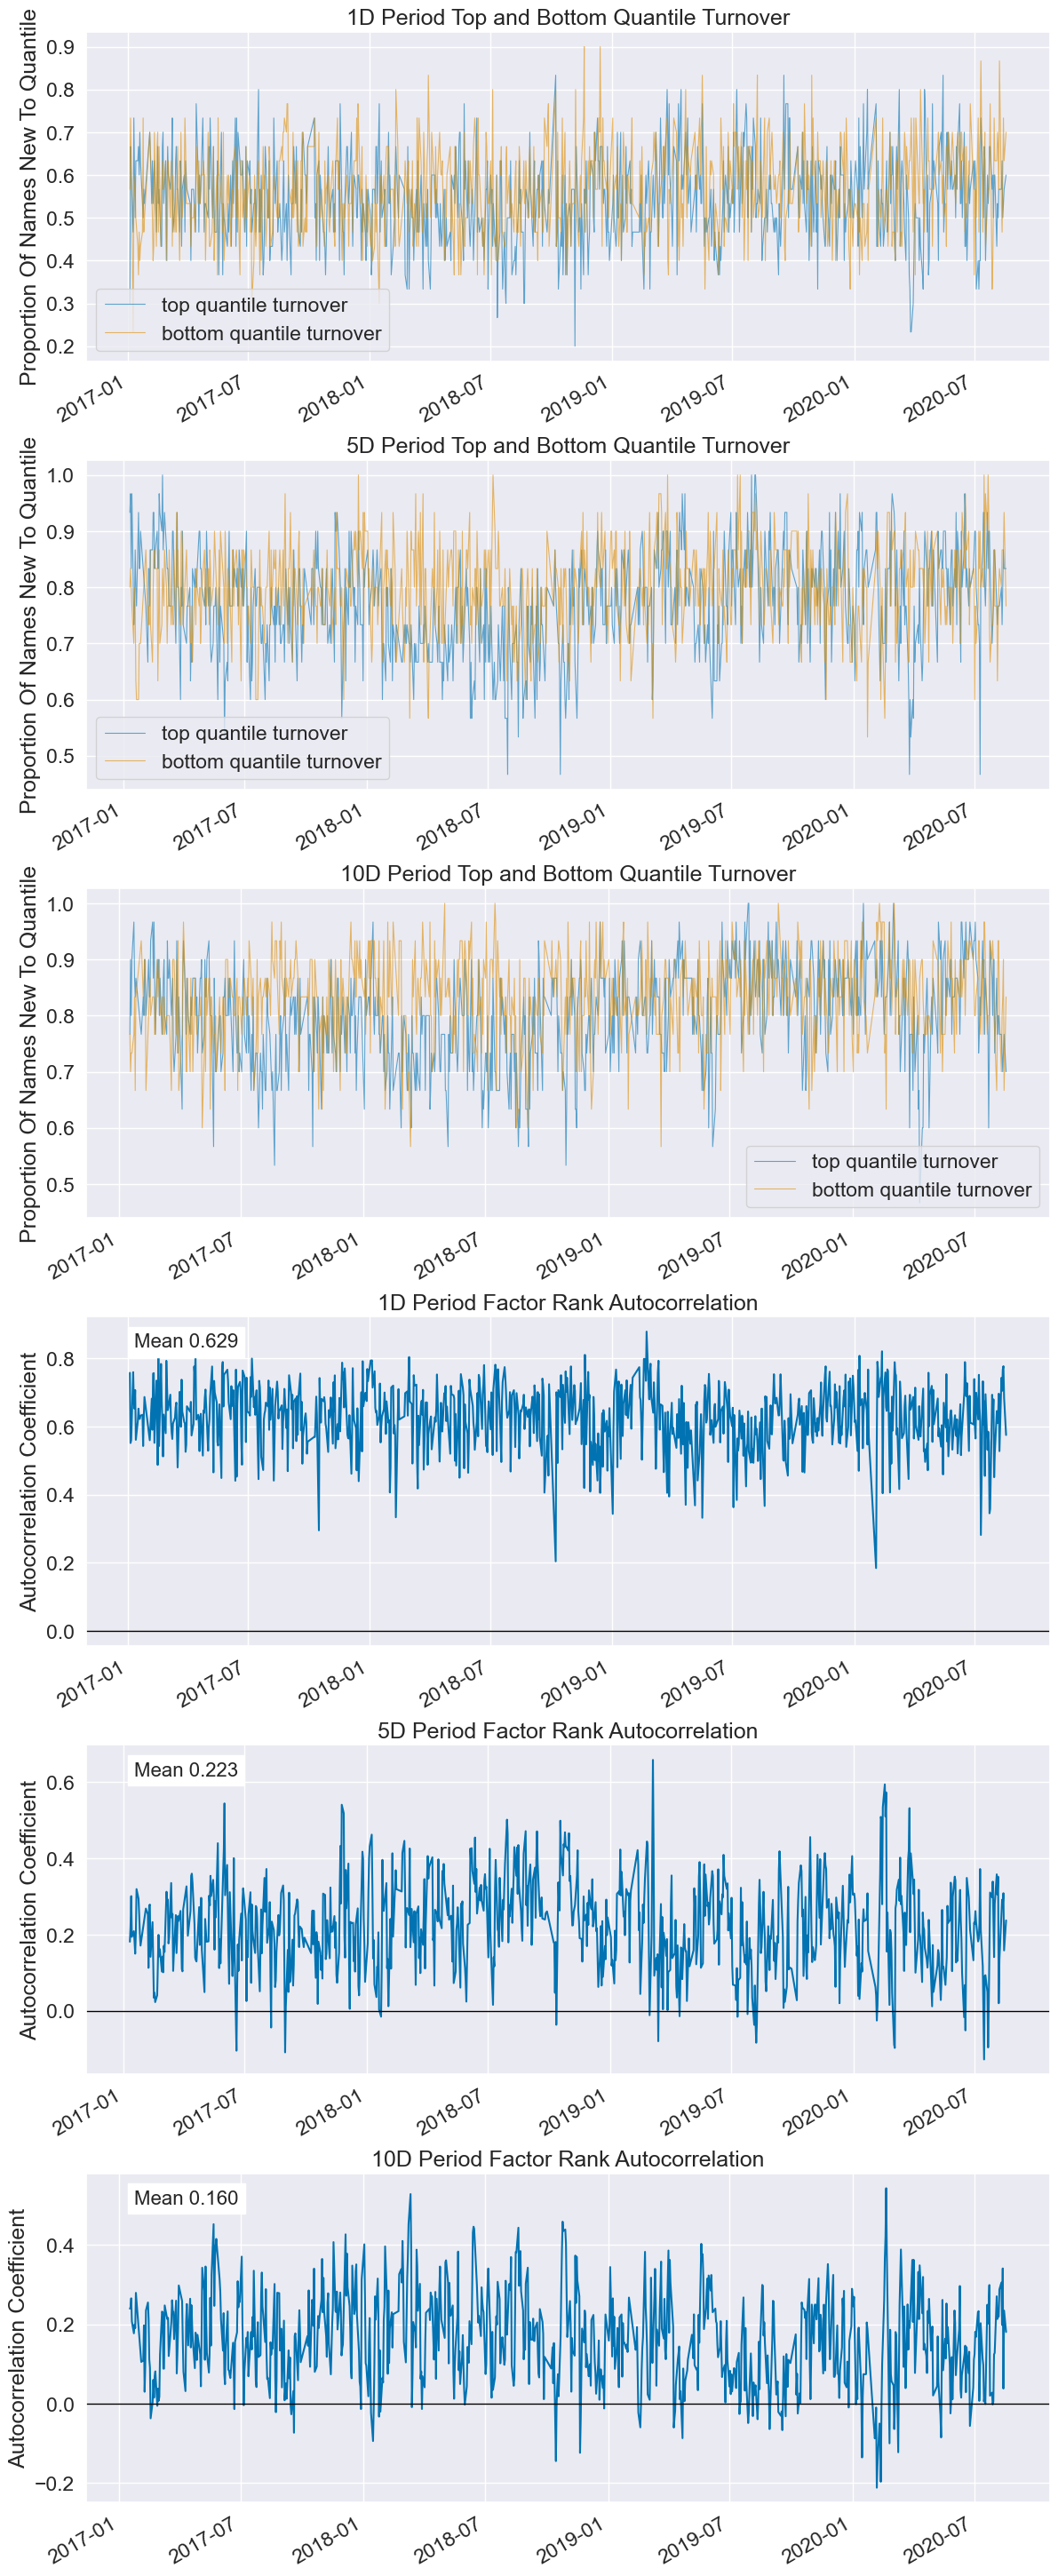

In [23]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [24]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [25]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

In [26]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [27]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [28]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2017, 1, 1),
    end=datetime(2020, 8, 1),
    capital=100000000
)

# 添加策略实例
setting = {"top_k": 30, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

2026-05-11 13:27:36 开始加载历史数据


100%|████████████████████████████████████████████████████████████████████████████████| 819/819 [00:08<00:00, 97.66it/s]

2026-05-11 13:27:44 部分合约历史数据为空：['600631.SSE', '600832.SSE', '601268.SSE', '601299.SSE', '688187.SSE', '600087.SSE', '600938.SSE', '301269.SZSE', '000562.SZSE', '688223.SSE', '600357.SSE', '000527.SZSE', '600941.SSE', '601825.SSE', '001289.SZSE', '300979.SZSE', '600102.SSE', '600786.SSE', '600591.SSE', '605117.SSE', '300999.SZSE', '601995.SSE', '300896.SZSE', '000024.SZSE', '688271.SSE', '300919.SZSE', '300866.SZSE', '688041.SSE', '300888.SZSE', '601868.SSE', '688303.SSE', '601059.SSE', '300957.SZSE', '688065.SSE', '600905.SSE', '601728.SSE', '605499.SSE', '600001.SSE']
2026-05-11 13:27:44 所有历史数据加载完成
2026-05-11 13:27:44 策略初始化完成
2026-05-11 13:27:44 开始回放历史数据


2026-05-11 13:27:50 历史数据回放结束
2026-05-11 13:27:50 开始计算逐日盯市盈亏
2026-05-11 13:27:51 逐日盯市盈亏计算完成
2026-05-11 13:27:51 开始计算策略统计指标
2026-05-11 13:27:51 ------------------------------
2026-05-11 13:27:51 首个交易日：  2017-01-03
2026-05-11 13:27:51 最后交易日：  2020-07-31
2026-05-11 13:27:51 总交易日：  871
2026-05-11 13:27:51 盈利交易日：  467
2026-05-11 13:27:51 亏损交易日：  403
2026-05-11 13:27:51 起始资金：  100,000,000.00
2026-05-11 13:27:51 结束资金：  231,711,555.63
2026-05-11 13:27:51 总收益率：  131.71%
2026-05-11 13:27:51 年化收益：  36.29%
2026-05-11 13:27:51 最大回撤:   -42,438,182.84
2026-05-11 13:27:51 百分比最大回撤: -27.33%
2026-05-11 13:27:51 最长回撤天数:   150
2026-05-11 13:27:51 总盈亏：  131,711,555.63
2026-05-11 13:27:51 总手续费：  16,816,267.15
2026-05-11 13:27:51 总成交金额：  22,449,155,430.72
2026-05-11 13:27:51 总成交笔数：  4860
2026-05-11 13:27:51 日均盈亏：  151,218.78
2026-05-11 13:27:51 日均手续费：  19,306.85
2026-05-11 13:27:51 日均成交金额：  25,774,001.64
2026-05-11 13:27:51 日均成交笔数：  5.579793340987371
2026-05-11 13:27:51 日均收益率：  0.11%
2026-05-11 13:27:51 收益标准差：

D:\veighna_studio\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning:

urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!



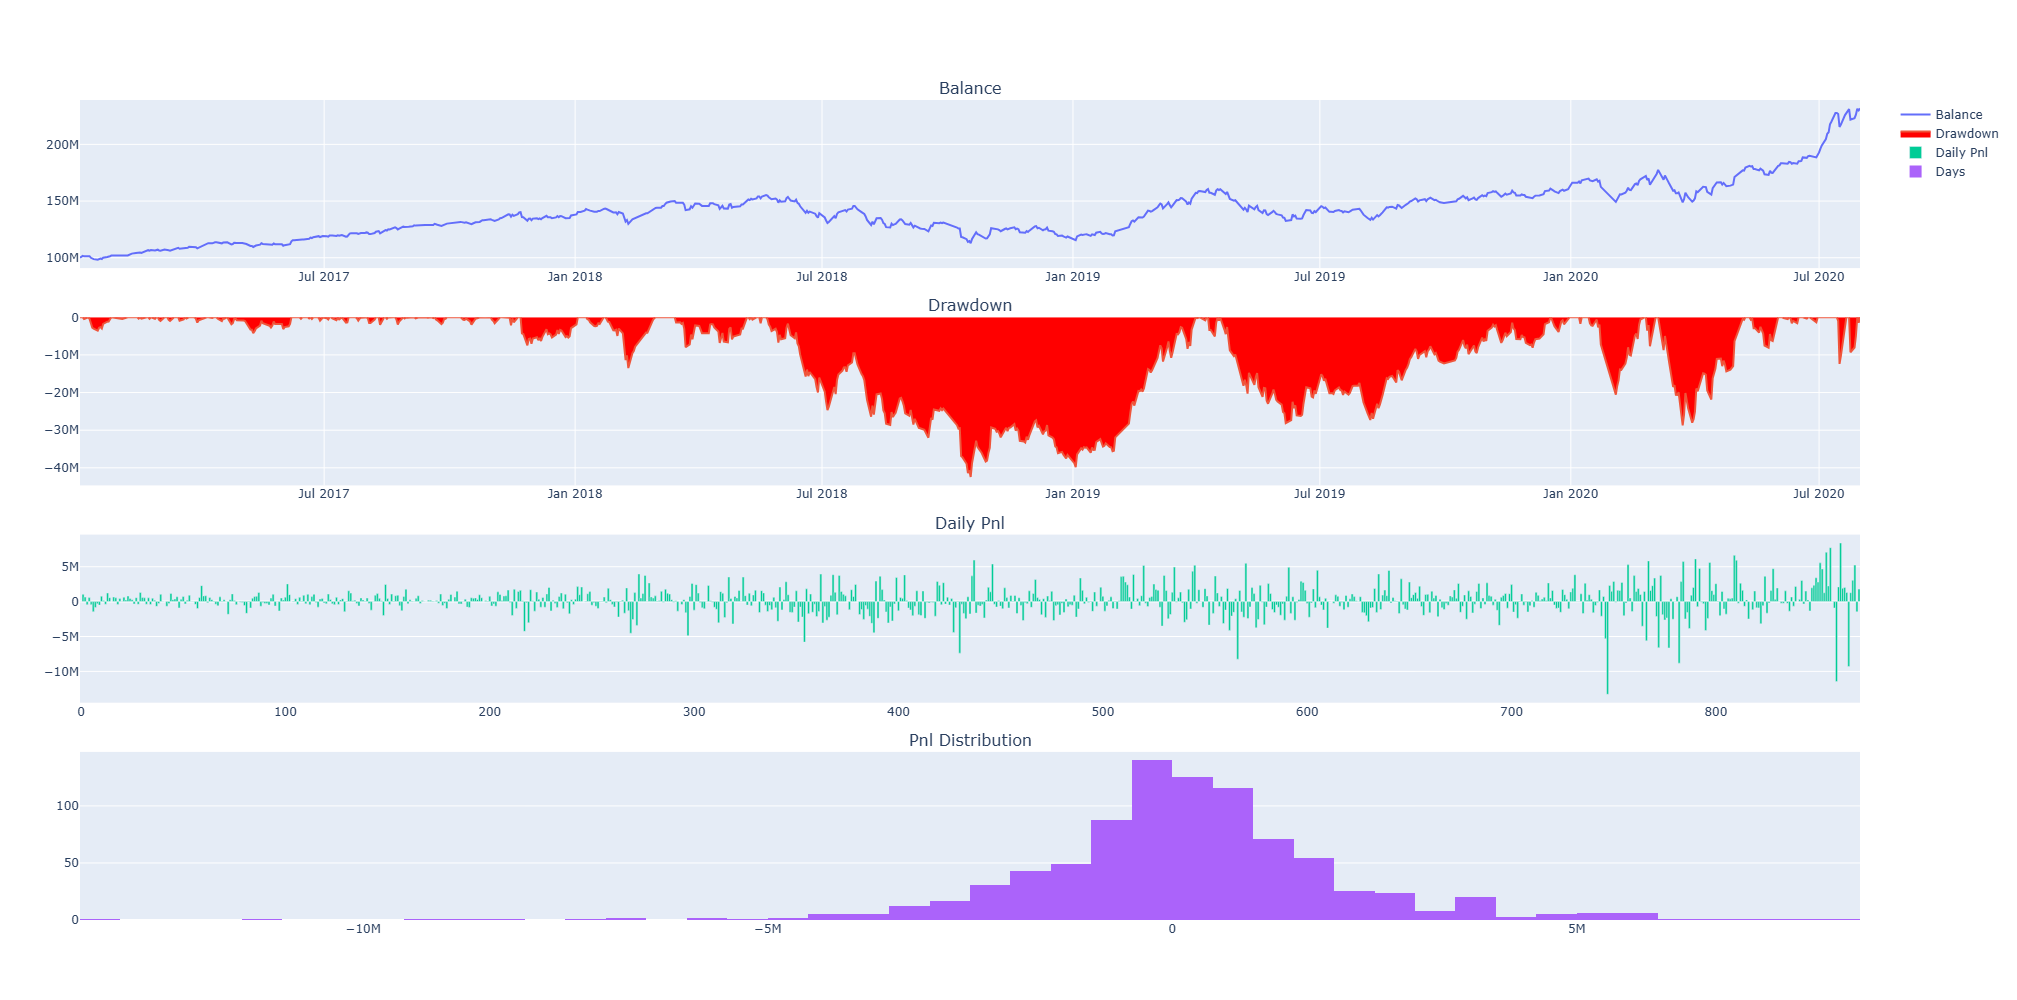

In [29]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

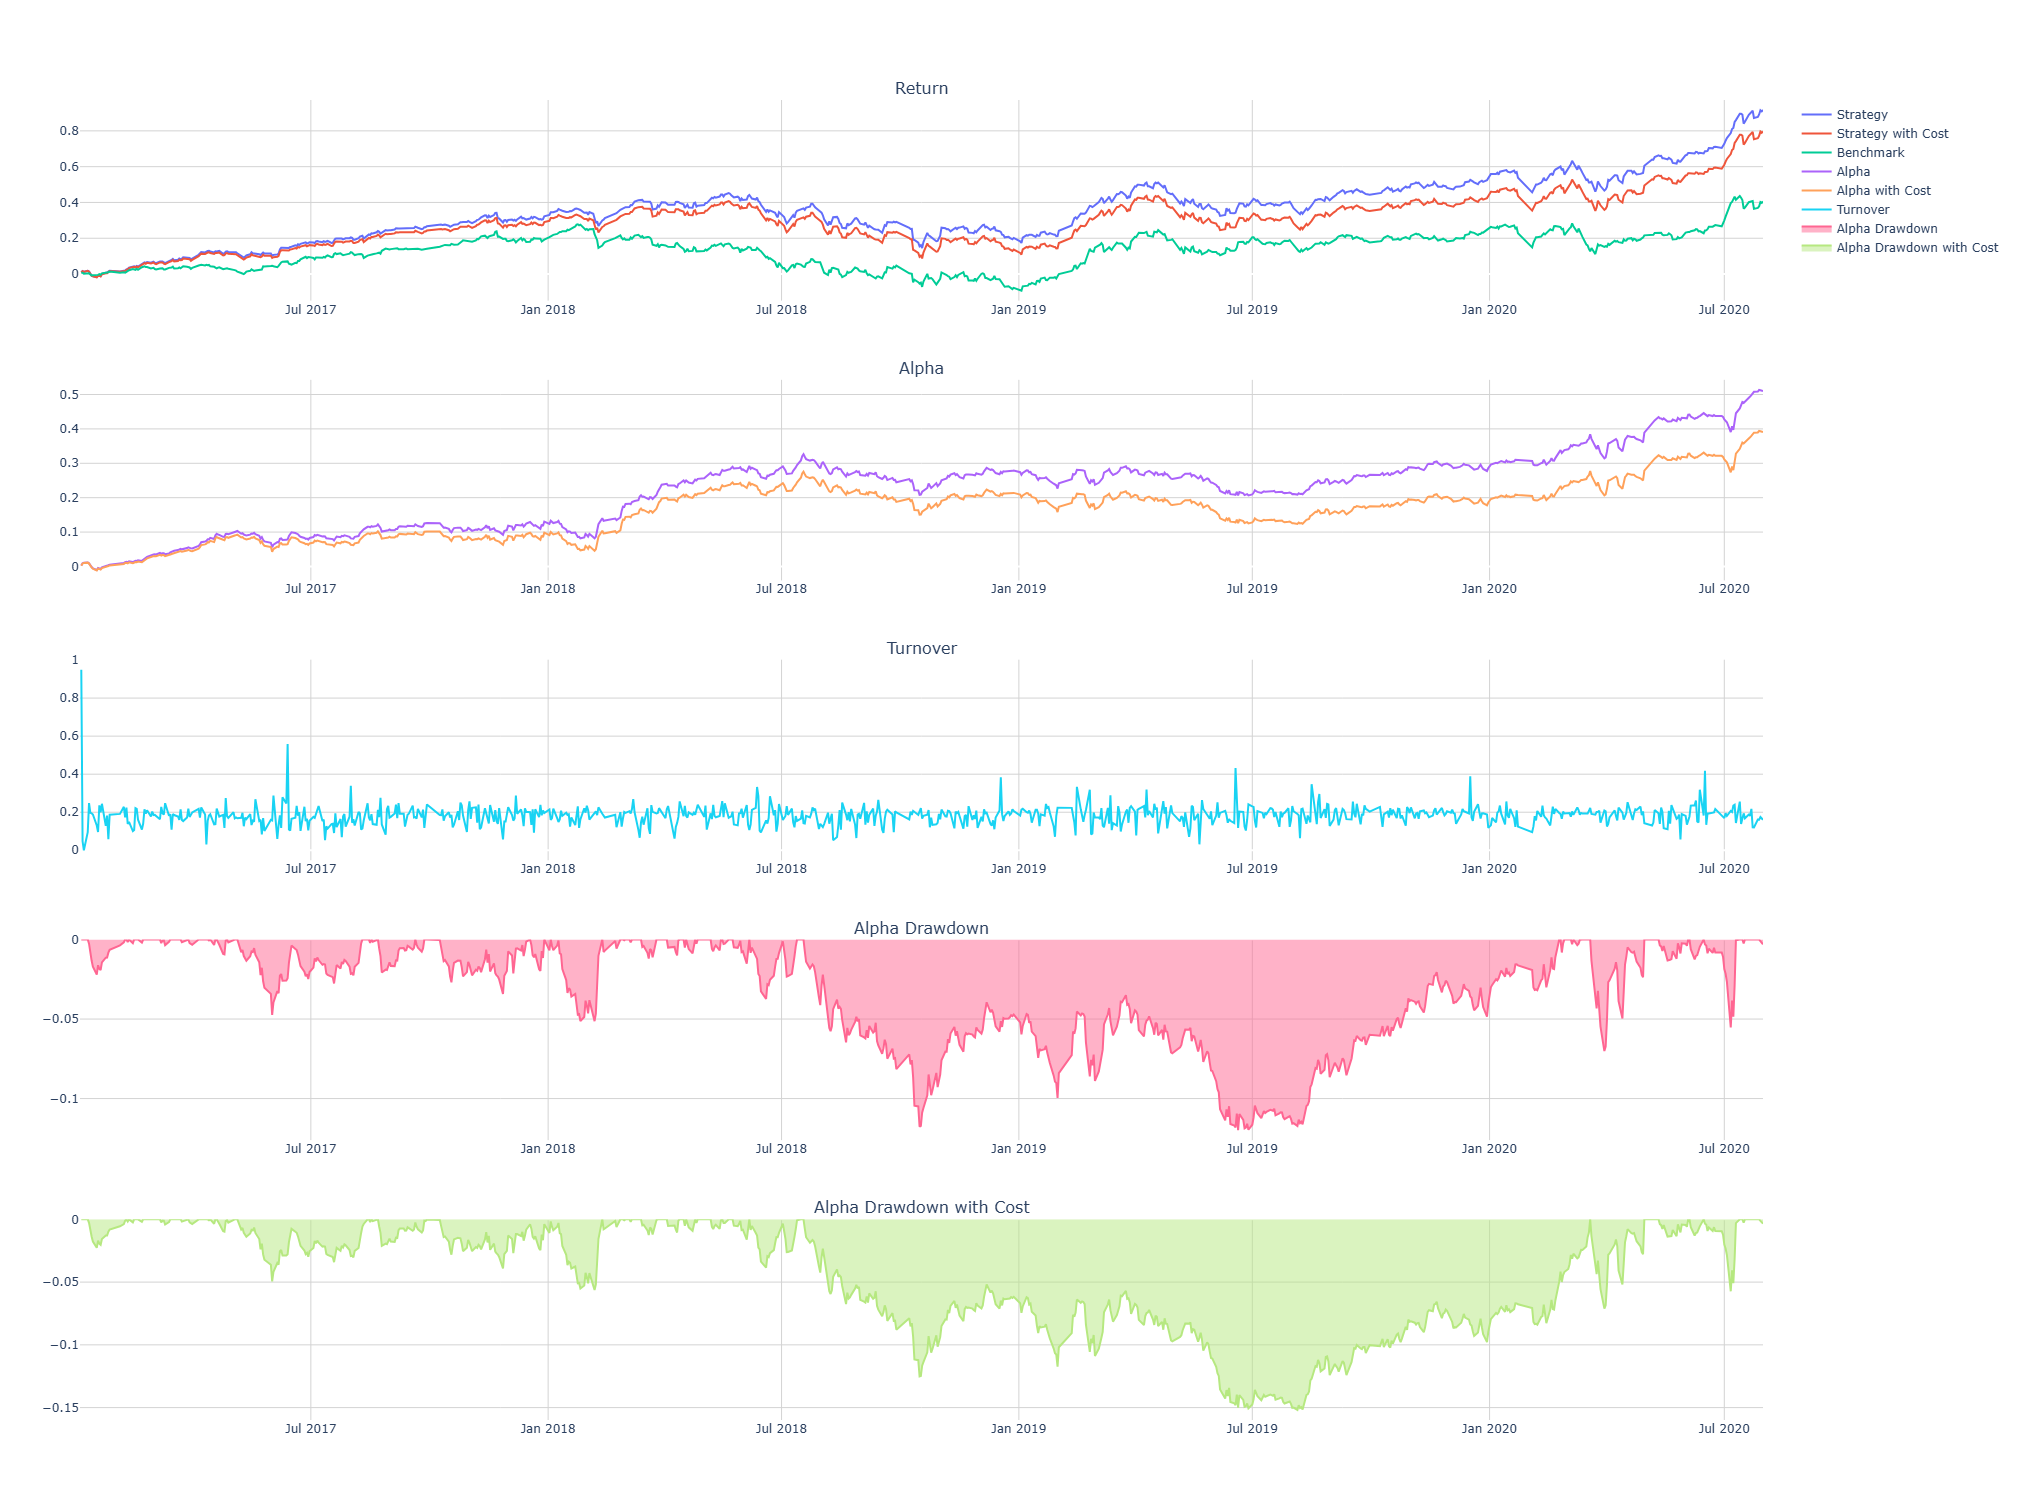

In [30]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)